1. Preprocesamiento de los datos

In [4]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import json

1.1 Descarga y Preparación del Dataset

In [5]:
# Cargar credenciales desde 'kaggle.json'
with open('./kaggle.json') as f:
    kaggle_credentials = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']

# Autenticación y descarga del dataset
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
api.dataset_download_files('carlosrunner/pizza-not-pizza', path='data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/carlosrunner/pizza-not-pizza


1.2 Exploración de Imágenes

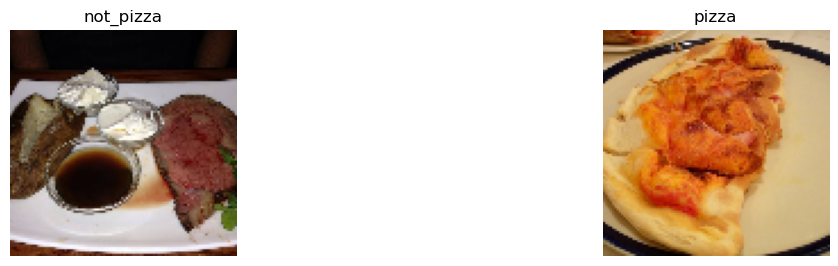

In [6]:
# Directorio de imágenes y categorías
data_dir = 'data/pizza_not_pizza'

pizza_categories = [
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d))
]

# Visualización de imágenes originales
plt.figure(figsize=(12, 10))

for i, category in enumerate(pizza_categories):
    folder = os.path.join(data_dir, category)
    
    # Asegurarse de que haya imágenes
    images = os.listdir(folder)
    if len(images) == 0:
        continue
    
    image_file = images[0]
    img_path = os.path.join(folder, image_file)

    # Cargar imagen
    img = keras.preprocessing.image.load_img(img_path, target_size=(100, 100))
    img_array = keras.preprocessing.image.img_to_array(img) / 255.0

    plt.subplot(4, 2, i+1)
    plt.imshow(img_array)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

1.3 Preparación de Datos y División en Entrenamiento, Validación y Test

In [7]:
# Recopilación de rutas y etiquetas
filepaths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(data_dir)
             for f in filenames if os.path.splitext(f)[1].lower() in ['.png','.jpg','.jpeg']]
labels = [os.path.split(os.path.split(path)[0])[1] for path in filepaths]

# Crear un DataFrame con rutas y etiquetas
data_df = pd.DataFrame({'filepath': filepaths, 'label': labels})

# División de datos: 70% entrenamiento, 30% para validación y test (10% test, 20% validación)
from sklearn.model_selection import train_test_split
train_df, test_val_df = train_test_split(data_df, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_val_df, test_size=2/3, random_state=42)

print("Total de imágenes:", len(data_df))
print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))

Total de imágenes: 1966
Entrenamiento: 1376
Validación: 394
Test: 196


1.4 Procesamiento y Generadores de Imágenes

In [8]:
# Generador para el conjunto de entrenamiento con data augmentation
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

# Generador para validación y test (solo reescala)
test_val_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

# Crear los generadores a partir de los DataFrames
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32
)
val_gen = test_val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32, shuffle=False
)
test_gen = test_val_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(100, 100), batch_size=32, shuffle=False
)

Found 1376 validated image filenames belonging to 2 classes.
Found 394 validated image filenames belonging to 2 classes.
Found 196 validated image filenames belonging to 2 classes.


Se aplicaron técnicas de preprocesamiento para mejorar el desempeño del modelo. En primer lugar, se utilizó normalización mediante el reescalado de los valores de píxeles al rango [0,1], lo cual facilita la convergencia durante el entrenamiento. Además, se implementó aumentación de datos en el conjunto de entrenamiento mediante rotaciones y volteos horizontales, con el fin de incrementar la variabilidad de las imágenes y reducir el sobreajuste. No se aplicó estandarización, ya que la normalización fue suficiente para estabilizar el entrenamiento en este caso.

2. Construcción de un Modelo de Red Neuronal Perceptrón Multicapa

In [9]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout

print(len(pizza_categories))

model = Sequential([
    Flatten(input_shape=(100, 100, 3)),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dense(len(pizza_categories), activation='sigmoid')
])

# Resumen del modelo y su arquitectura
model.summary()

# Compilar el modelo
model.compile(optimizer='adam', # Determina cómo se actualizan los pesos de la red durante el entrenamiento
              loss='binary_crossentropy', # Mide qué tan bien el modelo está haciendo predicciones
              metrics=['accuracy']) # Monitorear el rendimiento del modelo durante el entrenamiento y la prueba

2


/opt/anaconda3/envs/notebook_1/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    15,360,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,492,354 (59.10 MB)

 Trainable params: 15,492,354 (59.10 MB)

 Non-trainable params: 0 (0.00 B)

La arquitectura seleccionada se justifica como una solución adecuada para un problema de clasificación binaria en una etapa inicial de experimentación, priorizando simplicidad y eficiencia computacional. El uso de capas densas permite modelar relaciones no lineales a partir de las características extraídas de las imágenes, mientras que la inclusión de regularización mediante Dropout contribuye a mitigar el sobreajuste dado el alto número de parámetros inherente a este tipo de modelos. La elección del optimizador Adam favorece una convergencia rápida y estable durante el entrenamiento. Asimismo, la utilización de la función de pérdida binary_crossentropy resulta apropiada al tratarse de un problema binario, ya que permite cuantificar de manera efectiva la diferencia entre las probabilidades predichas y las etiquetas reales, facilitando un aprendizaje más preciso del modelo.

3. Definición de Funciones de Callbacks para Monitorear el Entrenamiento

In [10]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True,
                                   monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

El uso de callbacks en esta arquitectura resulta una decisión adecuada, ya que permite compensar las limitaciones inherentes a un modelo MLP aplicado a imágenes, el cual tiende a sobreajustarse debido al alto número de parámetros. En este contexto, EarlyStopping contribuye a detener el entrenamiento en el punto óptimo antes de que el modelo comience a memorizar los datos, mientras que ReduceLROnPlateau facilita un ajuste más fino de los pesos cuando el aprendizaje se estanca, mejorando la convergencia. Por su parte, ModelCheckpoint garantiza la conservación del mejor modelo obtenido durante el entrenamiento, evitando perder configuraciones óptimas. En conjunto, estos mecanismos permiten lograr un equilibrio entre capacidad de aprendizaje y generalización, optimizando el desempeño del modelo sin necesidad de incrementar su complejidad.

4. Entrenamiento y Exploración de Resultados

In [11]:
with tf.device('/device:GPU:0'):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        callbacks=callbacks
    )

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5292 - loss: 4.8840

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.5610 - loss: 2.9189 - val_accuracy: 0.6421 - val_loss: 0.6971 - learning_rate: 0.0010
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6105 - loss: 0.7968 - val_accuracy: 0.5533 - val_loss: 0.7445 - learning_rate: 0.0010
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6032 - loss: 0.7263

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.6032 - loss: 0.7255 - val_accuracy: 0.6244 - val_loss: 0.6319 - learning_rate: 0.0010
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6068 - loss: 0.6861 - val_accuracy: 0.5635 - val_loss: 0.7576 - learning_rate: 0.0010
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6235 - loss: 0.6558 - val_accuracy: 0.6218 - val_loss: 0.6556 - learning_rate: 0.0010
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6135 - loss: 0.6527

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.6468 - loss: 0.6355 - val_accuracy: 0.6650 - val_loss: 0.6171 - learning_rate: 0.0010
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.6206 - loss: 0.6455 - val_accuracy: 0.6548 - val_loss: 0.6184 - learning_rate: 0.0010
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5923 - loss: 0.6691 - val_accuracy: 0.6396 - val_loss: 0.6453 - learning_rate: 0.0010
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6105 - loss: 0.6544 - val_accuracy: 0.6523 - val_loss: 0.6315 - learning_rate: 0.0010
Epoch 10/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6135 - loss: 0.6352

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5981 - loss: 0.6472 - val_accuracy: 0.6624 - val_loss: 0.6123 - learning_rate: 0.0010
Epoch 11/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6156 - loss: 0.6449 - val_accuracy: 0.6396 - val_loss: 0.6439 - learning_rate: 0.0010
Epoch 12/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.6032 - loss: 0.6512 - val_accuracy: 0.6041 - val_loss: 0.6607 - learning_rate: 0.0010
Epoch 13/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6277 - loss: 0.6319

...

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6919 - loss: 0.5893 - val_accuracy: 0.6954 - val_loss: 0.5844 - learning_rate: 1.0000e-05
Epoch 40/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6933 - loss: 0.5922 - val_accuracy: 0.7030 - val_loss: 0.5847 - learning_rate: 1.0000e-05
Epoch 41/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7154 - loss: 0.5809

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6940 - loss: 0.5877 - val_accuracy: 0.7030 - val_loss: 0.5836 - learning_rate: 1.0000e-05
Epoch 42/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6868 - loss: 0.5951 - val_accuracy: 0.7030 - val_loss: 0.5838 - learning_rate: 1.0000e-05
Epoch 43/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6674 - loss: 0.5967

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6860 - loss: 0.5912 - val_accuracy: 0.7005 - val_loss: 0.5836 - learning_rate: 1.0000e-05
Epoch 44/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.6810 - loss: 0.5932 - val_accuracy: 0.7005 - val_loss: 0.5840 - learning_rate: 1.0000e-05
Epoch 45/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6904 - loss: 0.5894 - val_accuracy: 0.7005 - val_loss: 0.5841 - learning_rate: 1.0000e-05
Epoch 46/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6794 - loss: 0.5910
Epoch 46: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.6846 - loss: 0.5872 - val_accuracy: 0.7030 - val_loss: 0.5836 - learning_rate: 1.0000e-05
Epoch 47/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.6897 - loss: 0.5891 - val_accuracy: 0.7030 - val_loss: 0.5836 - learning_rate: 1.0000e-06
Epoch 48/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.6926 - loss: 0

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6875 - loss: 0.5760 - val_accuracy: 0.7030 - val_loss: 0.5836 - learning_rate: 1.0000e-06
Epoch 50/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6688 - loss: 0.5967

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6802 - loss: 0.5892 - val_accuracy: 0.7030 - val_loss: 0.5835 - learning_rate: 1.0000e-06


4.1 Evaluación del Modelo

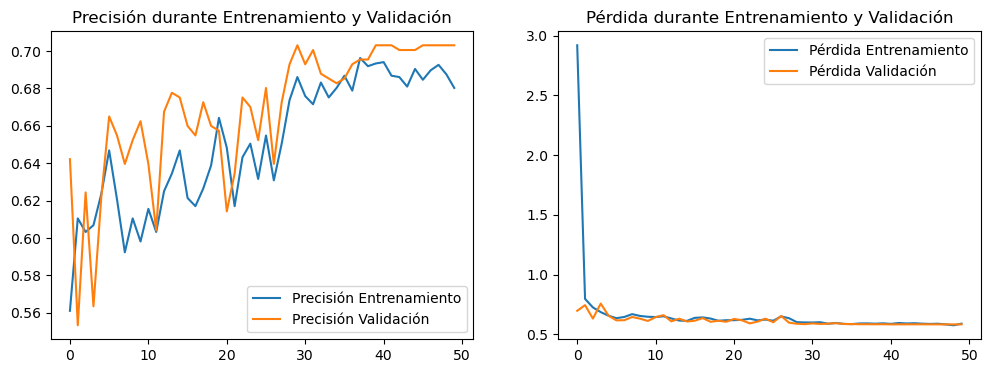

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


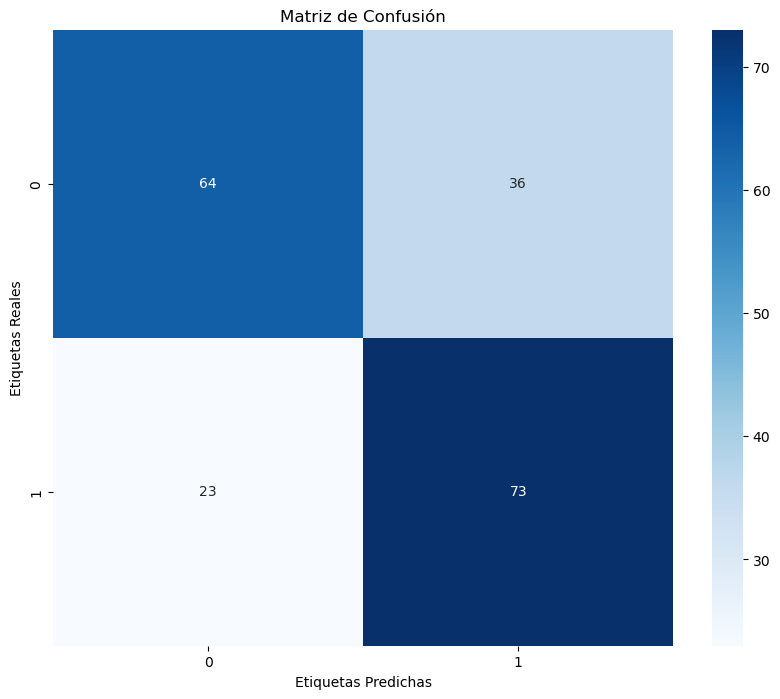

              precision    recall  f1-score   support

   not_pizza       0.74      0.64      0.68       100
       pizza       0.67      0.76      0.71        96

    accuracy                           0.70       196
   macro avg       0.70      0.70      0.70       196
weighted avg       0.70      0.70      0.70       196



In [12]:
# Visualización de la evolución del entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión Validación')
plt.legend(loc='lower right')
plt.title('Precisión durante Entrenamiento y Validación')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida Validación')
plt.legend(loc='upper right')
plt.title('Pérdida durante Entrenamiento y Validación')
plt.show()

from keras.models import load_model

# Cargar el mejor modelo guardado
best_model = load_model('best_model.h5')

# Evaluación en el conjunto de test
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_gen.reset()
predictions = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_test = test_gen.classes

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.ylabel('Etiquetas Reales')
plt.xlabel('Etiquetas Predichas')
plt.show()

# Reporte de Clasificación
print(classification_report(y_test, y_pred, target_names=pizza_categories))